# The EDA and Preprocessing Notebook

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

In [5]:
df = pd.read_csv('/content/drive/MyDrive/imdb/imdb_top_1000.csv')

In [6]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 16)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [9]:
df['Gross'] = df['Gross'].str.replace(',', '').astype(float)


AttributeError: Can only use .str accessor with string values!

In [10]:
df['Runtime'] = df['Runtime'].str.replace(' min', '').astype(int)

In [11]:
df['Meta_score'] = df['Meta_score'].fillna(df['Meta_score'].median())

In [12]:
df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')

In [13]:
print("Data Cleaning Complete!")

Data Cleaning Complete!


/tmp/ipykernel_12491/1168866726.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_df.head(15), x="Count", y="Genre", palette="magma")


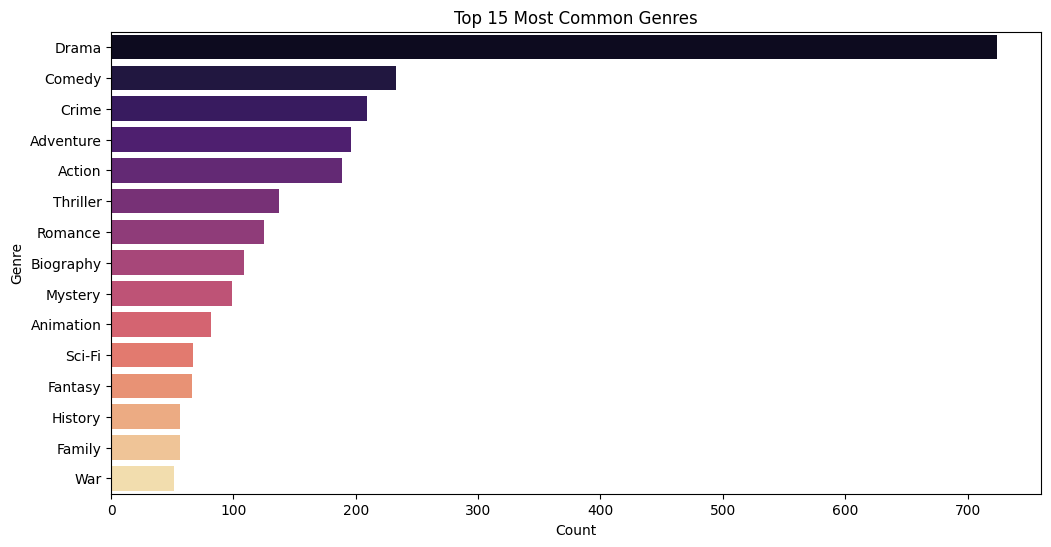

The most frequent genre is : Drama


In [14]:
all_genres = []
for g in df['Genre'].dropna():
  all_genres.extend([genre.strip() for genre in g.split(',')])

genre_counts = Counter(all_genres)
genre_df = pd.DataFrame(genre_counts.most_common(), columns=["Genre", "Count"])

# visualization
plt.figure(figsize=(12,6))
sns.barplot(data=genre_df.head(15), x="Count", y="Genre", palette="magma")
plt.title("Top 15 Most Common Genres")
plt.show()

print(f"The most frequent genre is : {genre_df.iloc[0]["Genre"]}")

In [15]:
# We create a new column specifically for our "Context Search"
def create_search_content(row):
    return (f"Title: {row['Series_Title']}. "
            f"Genre: {row['Genre']}. "
            f"Director: {row['Director']}. "
            f"Stars: {row['Star1']}, {row['Star2']}. "
            f"Overview: {row['Overview']}")

df['ai_context'] = df.apply(create_search_content, axis=1)

# Save the cleaned version for easy use later
df.to_csv('cleaned_imdb_data.csv', index=False)
print("Prepared 'ai_context' column and saved cleaned_imdb_data.csv")

Prepared 'ai_context' column and saved cleaned_imdb_data.csv


# Generating Vectors in Google Colab

In [16]:
!pip install -q sentence-transformers

In [17]:
from sentence_transformers import SentenceTransformer

In [18]:
import numpy as np

In [19]:
model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [20]:
sentences = df['ai_context'].tolist()

In [21]:
print(f"Starting embedding for {len(sentences)} movies...")
embeddings = model.encode(sentences, show_progress_bar=True)
df['vector'] = embeddings.tolist()
print("Success! Every movie now has a 384-dimensional vector representation.")
print(f"Example vector for '{df.iloc[0]['Series_Title']}': {df.iloc[0]['vector'][:5]}... (truncated)")

Starting embedding for 1000 movies...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Success! Every movie now has a 384-dimensional vector representation.
Example vector for 'The Shawshank Redemption': [-0.09052577614784241, -0.05868441238999367, -0.0436905138194561, -0.03165155276656151, -0.0015502916648983955]... (truncated)


In [24]:
!pip install -q pinecone
from pinecone import Pinecone, ServerlessSpec

PINECONE_API_KEY = ""
pc = Pinecone(api_key=PINECONE_API_KEY)

index_name = "movie-chatbot"

# Check if it already exists don't error out
if index_name not in pc.list_indexes().names():
    print(f"Creating index '{index_name}'...")
    pc.create_index(
        name=index_name,
        dimension=384,
        metric='cosine',
        spec=ServerlessSpec(
            cloud='aws',
            region='us-east-1' # Standard free tier region
        )
    )
    print("Index created successfully!")
else:
    print(f"Index '{index_name}' already exists.")

index = pc.Index(index_name)

print("Starting upload to Pinecone...")

victors_to_upsert = []

for i, row in df.iterrows():
    # Convert vector to list of floats
    v = row['vector']

    # Metadata: This is what the LLM will see in the search results
    meta = {
        "title": str(row['Series_Title']),
        "genre": str(row['Genre']),
        "director": str(row['Director']),
        "overview": str(row['Overview']),
        "poster": str(row['Poster_Link']),
        "rating": float(row['IMDB_Rating'])
    }

    # Pinecone format: (ID, Vector, Metadata)
    victors_to_upsert.append((str(i), v, meta))

    # Upload in batches of 100
    if len(victors_to_upsert) == 100:
        index.upsert(vectors=victors_to_upsert)
        victors_to_upsert = []

# Upload any remaining vectors
if victors_to_upsert:
    index.upsert(vectors=victors_to_upsert)

print(f"Successfully uploaded {len(df)} movies to Pinecone!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 742.7/742.7 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.9/280.9 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.1 MB/s eta 0:00:00
Creating index 'movie-chatbot'...
Index created successfully!
Starting upload to Pinecone...
Successfully uploaded 1000 movies to Pinecone!
